# Projet 9 - Mise en place d'un système RAG

#### Liste des imports du projet

In [1]:
import pandas as pd
pd.set_option('display.max_columns', None)   # affiche toutes les colonnes
pd.set_option('display.max_rows', 100)        # affiche jusqu'à 100 lignes (ajuste selon besoin)
pd.set_option('display.width', None)          # n'impose pas de largeur max, s'adapte au contenu
pd.set_option('display.max_colwidth', None)

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import missingno as msno
import torch
import langchain
import mistralai
import os

from langchain_community.vectorstores import FAISS
from langchain_huggingface import HuggingFaceEmbeddings
from mistralai.client import Mistral

C:\Users\Cheun\AppData\Local\Temp\ipykernel_3312\4129900634.py:16: DeprecationWarning: `langchain-community` is being sunset and is no longer actively maintained. See https://github.com/langchain-ai/langchain-community/issues/674 for details and migration guidance toward standalone integration packages.
  from langchain_community.vectorstores import FAISS


#### Importation des données du projet

Ici, nous avons sélectionné les événements culturels ayant eu lieu en bretagne sur toute la période 2026 et s'étalant jusqu'à 2027. Les données ont été exportées manuellement directement sur l'API OpenAgenda au format JSON.

In [2]:
from pathlib import Path

ROOT = Path.cwd().parent
DATA_FILE = ROOT/"data"
DATA = DATA_FILE / "data.json"

df = pd.read_json(DATA)

In [3]:
#Visualisation rapide de la composition du dataframe obtenue.
display(df)
print(df.shape)

,uid,slug,canonicalurl,title_fr,description_fr,longdescription_fr,conditions_fr,keywords_fr,image,imagecredits,thumbnail,originalimage,updatedat,daterange_fr,firstdate_begin,firstdate_end,lastdate_begin,lastdate_end,timings,accessibility,accessibility_label_fr,location_uid,location_coordinates,location_name,location_address,location_district,location_insee,location_postalcode,location_city,location_department,location_region,location_countrycode,location_image,location_imagecredits,location_phone,location_website,location_links,location_tags,location_description_fr,location_access_fr,attendancemode,onlineaccesslink,status,age_min,age_max,originagenda_title,originagenda_uid,contributor_email,contributor_contactnumber,contributor_contactname,contributor_contactposition,contributor_organization,category,country_fr,registration,links
0,42512026,le-voyage-dans-la-lune-marcel-dzama-7015150,https://openagenda.com/sortir-rennesmetropole/events/le-voyage-dans-la-lune-marcel-dzama-7015150,"« Le voyage dans la Lune », Marcel Dzama","« Le voyage dans la Lune » présente l’univers de l’artiste canadien Marcel Dzama à La Criée. Films, dessins et sculptures rendent hommage à Méliès et dévoilent un monde poétique, fantasque et politiq…","<p>La Criée présente du 14 février au 10 mai 2026 une exposition de Marcel Dzama, artiste canadien basé à New York, internationalement reconnu, mais rarement exposé en France. Intitulée « Le voyage dans la Lune », en clin d’œil au magicien des débuts du cinéma Georges Méliès, elle présente pour la première fois en Europe une large sélection des films de l’artiste, auxquels font écho un ensemble de storyboards, dessins, maquettes et costumes.</p>\n<p>Formé aux beaux-arts de Winnipeg, sa ville natale, immergé dès ses débuts dans les cultures populaires alternatives (il a notamment fait partie de groupes de rock et produit de nombreux fanzines), Marcel Dzama développe depuis la fin des années 1990 une œuvre foisonnante et joyeuse, au sein de laquelle la pratique du dessin et du film sont centrales.<br>Grand admirateur et fin connaisseur des débuts du cinéma (auquel nombre de ses films empruntent notamment le noir et blanc et la gestuelle expressionniste), Marcel Dzama est, plus largement, curieux d’univers variés : l’esprit surréaliste, les débuts du modernisme, la pop culture, l’illustration, la musique underground, etc. Ces références, qu’on reconnaîtra ou pas, nourrissent un univers de fantaisie – immédiatement reconnaissable lui -, tantôt merveilleux, tantôt cruel, tantôt poétique, tantôt politique.</p>\n<p>L’exposition « Le voyage dans la Lune » propose une quinzaine de films. À travers un programme d’une heure, imaginé par l’artiste, on découvre des films de jeunesse, des films tournés sur le vif, d’autres avec son fils et son père, d’autres encore produits dans le cadre de commandes. L’humour et l’inventivité irriguent d’une même énergie cette sélection. Marcel Dzama a par ailleurs choisi de mettre en avant deux films, présentés dans deux salles dédiées : « Une danse des bouffons » (2013) et « To live on the Moon (for lorca) » (2023). Le premier est inspiré par l’histoire d’amour entre Marcel Duchamp et la sculptrice Maria Martins, le second par les figures de la lune et du poète Frederico Garcia Lorca.</p>\n<p>En rebond aux films, des objets, sculptures, masques, dessins, maquettes, storyboard dessinés sont présentés dans l’espace central du centre d’art. Qu’ils s’agissent de costumes, d’éléments de décor ou de carnets dessins directement issus des films ou de dessins réalisés par ailleurs, on y retrouve, en couleur et en trait, les mêmes inspirations et la même facétie.</p>\n<p>Du crayon à la caméra, du poétique au politique, Marcel Dzama joue avec les codes et l’histoire du burlesque et du fantastique, avec une virtuosité de funambule. Ses œuvres mêlent références et pirouettes virtuoses avec un plaisir, une liberté et une joie qu’on espère contagieuses.</p>",Gratuit,[Exposition],https://cdn.openagenda.

(2424, 56)


## Phases d'exploration des données et de nettoyage

In [4]:
# Compréhension du dataframe
print("-"*100)
print("Liste des colonnes")
print(list(df.columns))

----------------------------------------------------------------------------------------------------
Liste des colonnes
['uid', 'slug', 'canonicalurl', 'title_fr', 'description_fr', 'longdescription_fr', 'conditions_fr', 'keywords_fr', 'image', 'imagecredits', 'thumbnail', 'originalimage', 'updatedat', 'daterange_fr', 'firstdate_begin', 'firstdate_end', 'lastdate_begin', 'lastdate_end', 'timings', 'accessibility', 'accessibility_label_fr', 'location_uid', 'location_coordinates', 'location_name', 'location_address', 'location_district', 'location_insee', 'location_postalcode', 'location_city', 'location_department', 'location_region', 'location_countrycode', 'location_image', 'location_imagecredits', 'location_phone', 'location_website', 'location_links', 'location_tags', 'location_description_fr', 'location_access_fr', 'attendancemode', 'onlineaccesslink', 'status', 'age_min', 'age_max', 'originagenda_title', 'originagenda_uid', 'contributor_email', 'contributor_contactnumber', 'contri

| Colonne | Catégorie | Rôle | Verdict |
|---|---|---|---|
| uid | Identification | Identifiant unique de l'événement | Conserver — clé primaire, citation |
| slug | Identification | Identifiant texte lisible (url) | Conserver |
| canonicalurl | Identification | URL de la fiche événement | Conserver — lien source |
| originagenda_title | Identification | Nom de l'agenda ayant publié l'événement | Conserver |
| originagenda_uid | Identification | Id de l'agenda source | Conserver — utile pour détecter les doublons de syndication |
| status | Identification | Statut (programmé / reporté / annulé) | Conserver — à utiliser comme filtre qualité |
| title_fr | Texte événement | Titre | Conserver — texte à vectoriser |
| description_fr | Texte événement | Description courte | Conserver — texte à vectoriser |
| longdescription_fr | Texte événement | Description longue | Conserver — texte à vectoriser (fallback si vide) |
| conditions_fr | Texte événement | Conditions, tarifs | Conserver — répond à "gratuit ?", "sur inscription ?" |
| keywords_fr | Texte événement | Mots-clés / catégories | Conserver — base du filtre culturel |
| daterange_fr | Dates | Plage de dates déjà formatée en texte | Conserver |
| firstdate_begin | Dates | Date début 1ère occurrence | Conserver — filtrage temporel |
| firstdate_end | Dates | Date fin 1ère occurrence | Conserver |
| lastdate_begin | Dates | Date début dernière occurrence | Conserver |
| lastdate_end | Dates | Date fin dernière occurrence | Conserver |
| timings | Dates | Détail des créneaux horaires par occurrence | Optionnel — utile si horaires précis affichés, sinon dropper |
| updatedat | Dates | Date de dernière modification de la fiche | Conserver (léger) — traçabilité, rafraîchissement futur |
| image | Images | URL image événement | Dropper — pas d'UI visuelle prévue |
| imagecredits | Images | Crédit photo événement | Dropper |
| thumbnail | Images | Vignette | Dropper |
| originalimage | Images | Image source | Dropper |
| location_image | Images | Image du lieu | Dropper |
| location_imagecredits | Images | Crédit photo du lieu | Dropper |
| location_uid | Localisation | Identifiant du lieu | Conserver |
| location_coordinates | Localisation | Latitude/longitude | Conserver — utile pour une future recherche de proximité |
| location_name | Localisation | Nom du lieu | Conserver — texte |
| location_address | Localisation | Adresse | Conserver |
| location_postalcode | Localisation | Code postal | Conserver |
| location_city | Localisation | Ville | Conserver — cœur du filtre géographique |
| location_department | Localisation | Département | Conserver |
| location_region | Localisation | Région | Conserver |
| location_countrycode | Localisation | Code pays | Dropper — constant sur ton sous-ensemble |
| country_fr | Localisation | Pays (texte) | Dropper — constant |
| location_district | Localisation | Quartier | Dropper — peu pertinent hors grandes métropoles |
| location_insee | Localisation | Code INSEE commune | Dropper — hors scope POC |
| location_phone | Localisation | Téléphone du lieu | Conserver |
| location_website | Localisation | Site web du lieu | Conserver |
| location_links | Localisation | Liens additionnels du lieu | Dropper — sparse et secondaire |
| location_tags | Localisation | Tags du lieu | Dropper — sparse et redondant avec keywords_fr |
| location_description_fr | Localisation | Description du lieu | Dropper — sparse, secondaire pour le POC |
| location_access_fr | Localisation | Accès au lieu (transport...) | Conserver |
| attendancemode | Modalités / public | Présentiel / en ligne / hybride | Conserver |
| onlineaccesslink | Modalités / public | Lien si événement en ligne | Conserver |
| accessibility | Modalités / public | Accessibilité handicap (code) | Conserver malgré la sparsité — vraie valeur quand renseigné |
| accessibility_label_fr | Modalités / public | Accessibilité handicap (libellé) | Conserver malgré la sparsité |
| age_min | Modalités / public | Âge minimum ciblé | Conserver malgré la sparsité |
| age_max | Modalités / public | Âge maximum ciblé | Conserver malgré la sparsité |
| registration | Modalités / public | Modalités d'inscription | Conserver |
| links | Modalités / public | Liens additionnels (billetterie...) | Dropper — sparse, secondaire pour le POC |
| contributor_email | Admin / technique | Email du contributeur | Dropper — vide à 100 %, et personnel si renseigné |
| contributor_contactnumber | Admin / technique | Téléphone du contributeur | Dropper — vide à 100 % |
| contributor_contactname | Admin / technique | Nom du contributeur | Dropper — vide à 100 % |
| contributor_contactposition | Admin / technique | Poste du contributeur | Dropper — vide à 100 % |
| contributor_organization | Admin / technique | Organisation du contributeur | Dropper — vide à 100 % |
| category | Admin / technique | Catégorie | Dropper — vide à 100 % |

### Nettoyage des colonnes / events avec statut complet, annulé ou reporté / events avec keywords non culturels

In [5]:
# Colonnes écartées d'après le tableau ci-dessus (hors-scope pour le RAG,
# ou entièrement vides). "_occurrence" est une colonne technique créée plus
# bas, ajoutée ici pour qu'elle soit nettoyée avec le reste au même endroit.
list_col_drop = [
    "contributor_organization", "category", "contributor_contactposition",
    "contributor_contactname", "contributor_contactnumber", "contributor_email",
    "links", "location_insee", "location_countrycode", "location_imagecredits",
    "location_image", "originalimage", "thumbnail", "imagecredits", "image",
    "_occurrence",
]

In [6]:
print("-"*100)
print("Nombre de cellules null par variable")
print(df.isnull().sum())

print("-"*100)
print("Nombre de duplicats")
print(df['uid'].duplicated().sum())
print(df["slug"].duplicated().sum())
print(df["canonicalurl"].duplicated().sum())
print(df["title_fr"].duplicated().sum())
print(df["description_fr"].duplicated().sum())

----------------------------------------------------------------------------------------------------
Nombre de cellules null par variable
uid                               0
slug                              0
canonicalurl                      0
title_fr                          0
description_fr                    0
longdescription_fr              111
conditions_fr                   674
keywords_fr                       0
image                           120
imagecredits                   1079
thumbnail                       120
originalimage                   120
updatedat                         0
daterange_fr                      0
firstdate_begin                   0
firstdate_end                     0
lastdate_begin                    0
lastdate_end                      0
timings                           0
accessibility                  1806
accessibility_label_fr         1806
location_uid                      0
location_coordinates              0
location_name                     

On a observé qu'il y avait des duplicats au niveau du titre de l'événement, et de la description. Nous allons vérifié de quoi il s'agit.

In [7]:
dupes = df[df.duplicated(subset="title_fr", keep=False)].sort_values("title_fr")
dupes[["title_fr", "location_name", "firstdate_begin", "originagenda_uid", "uid"]]

,title_fr,location_name,firstdate_begin,originagenda_uid,uid
1290,"""Aux Abords de la Ville"" - Peintures et dessins de Sylvie Beaufils",La Cale,2026-05-17T15:00:00+02:00,38977657,1277727
897,"""Aux Abords de la Ville"" - Peintures et dessins de Sylvie Beaufils",La Cale,2026-04-19T15:00:00+02:00,38977657,12930153
1042,"""Aux Abords de la Ville"" - Peintures et dessins de Sylvie Beaufils",La Cale,2026-04-26T15:00:00+02:00,38977657,52008733
2190,"""Aux Abords de la Ville"" - Peintures et dessins de Sylvie Beaufils",La Cale,2026-05-03T15:00:00+02:00,38977657,71465843
215,"""Aux Abords de la Ville"" - Peintures et dessins de Sylvie Beaufils",La Cale,2026-05-10T15:00:00+02:00,38977657,77470732
...,...,...,...,...,...
597,À VOS AMOURS • ANNE-CÉCILE ESTEVE (FR),Quartier La Courrouze,2025-12-21T09:00:00+01:00,38977657,93447350
428,À VOS AMOURS • ANNE-CÉCILE ESTEVE (FR),Quartier La Courrouze,2025-11-30T09:00:00+01:00,38977657,51573645
596,À VOS AMOURS • ANNE-CÉCILE ESTEVE (FR),Quartier La Courrouze,2025-12-14T09:00:00+01:00,38977657,87990907
1568,À VOS AMOURS • ANNE-CÉCILE ESTEVE (FR),Quartier La Courrouze,2025-12-28T09:00:00+01:00,38977657,5669703


Nous observons des duplications d'événements qui proviennent en réalité de dates multiples pour un même évenemment (simplement un événements répétés régulièrement). Il est important pour la mise en base vectorielle que ces événements soient compactés en un seul car sinon en cas de question du type "top 5 des événements dans tel domaine" on pourrait avoir 5 fois le meme evenement qui sortirait pour des dates différentes. Nous allons donc aggrégés les évenements un un seul mais avec une conservation de l'ensemble des dates sous forme de liste.

In [8]:
# Premier essai de regroupement, à titre exploratoire (df encore complet,
# statut pas encore filtré). La version définitive, df_evenements_clean,
# est plus bas, une fois le filtre statut appliqué.

# 1. df de départ : 56 colonnes, ~2424 lignes (1 ligne = 1 séance)

# 2. colonne technique pour coupler début/fin de la même séance
df["_occurrence"] = list(zip(df["firstdate_begin"], df["firstdate_end"]))

# 3. uniquement les colonnes calculées, indexées par (titre, lieu)
agg_dates = (
    df.groupby(["title_fr", "location_name"])
      .agg(
          uids=("uid", list),
          dates=("_occurrence", lambda s: sorted(set(s))),
          date_min=("firstdate_begin", "min"),
          date_max=("lastdate_end", "max"),
          nb_occurrences=("uid", "count"),
      )
)

# 4. toutes les colonnes originales, une ligne par groupe (occurrence la plus ancienne)
representative = (
    df.sort_values("firstdate_begin")
      .groupby(["title_fr", "location_name"])
      .first()
)

# 5. on recolle les deux sur leur index commun (title_fr, location_name)
df_evenements = representative.join(
    agg_dates[["uids", "dates", "date_min", "date_max", "nb_occurrences"]]
).reset_index()

print(df.shape)
print(df_evenements.shape)
print(list(df_evenements.columns))

(2424, 57)
(2038, 62)
['title_fr', 'location_name', 'uid', 'slug', 'canonicalurl', 'description_fr', 'longdescription_fr', 'conditions_fr', 'keywords_fr', 'image', 'imagecredits', 'thumbnail', 'originalimage', 'updatedat', 'daterange_fr', 'firstdate_begin', 'firstdate_end', 'lastdate_begin', 'lastdate_end', 'timings', 'accessibility', 'accessibility_label_fr', 'location_uid', 'location_coordinates', 'location_address', 'location_district', 'location_insee', 'location_postalcode', 'location_city', 'location_department', 'location_region', 'location_countrycode', 'location_image', 'location_imagecredits', 'location_phone', 'location_website', 'location_links', 'location_tags', 'location_description_fr', 'location_access_fr', 'attendancemode', 'onlineaccesslink', 'status', 'age_min', 'age_max', 'originagenda_title', 'originagenda_uid', 'contributor_email', 'contributor_contactnumber', 'contributor_contactname', 'contributor_contactposition', 'contributor_organization', 'category', 'countr

Maintenant que nous avons aggégés les événements, nous pouvons effectuer le nettoyage réel du tableau avec la suppression des colonnes vides ou non-pertinentes pour une demande client sur un événement.

Nous avons maintenant un df qui est nettoyé et qui contient seulement les informations pertinentes pour un utilisateur. Nous avons donc regardé au niveau général et allons maintenant descencdre d'un cran en nous intéréssant réellement aux evenements, ont ils eu lieux (annulations) ? Est il encore possible de s'y inscrire (complet ou non) ? En prenant en compte la variable statut. Nous regarderons ensuite si les keywords des événements correspondent bien à ce que nous avons sélectionné et que nous avons bel et bien listé des évenements culturels.

In [9]:
# Nettoyage du statut : la colonne `status` est une chaîne JSON (id + libellés
# multilingues), pas une catégorie directement exploitable. On la parse pour
# ne garder que les événements réellement programmés AVANT de dédupliquer,
# afin qu'aucune séance annulée ne se retrouve cachée dans les listes de dates
# des événements récurrents regroupés plus bas.

import json

def parse_status(s):
    try:
        d = json.loads(s)
        return d["id"], d["label"].get("fr")
    except (TypeError, ValueError, KeyError):
        return None, None

df[["status_id", "status_label"]] = df["status"].apply(lambda s: pd.Series(parse_status(s)))
print(df["status_label"].value_counts())

df = df[df["status_id"] == 1].copy()
print(df.shape)  # attendu : ~2410 lignes

# garde-fou : arrête le notebook immédiatement si un statut non "Programmé"
# a échappé au filtre, plutôt que de laisser l'erreur se propager en silence
assert df["status_id"].eq(1).all()

status_label
Programmé    2410
Annulé          8
Complet         5
Reporté         1
Name: count, dtype: int64
(2410, 59)


In [10]:
# df est maintenant le DataFrame filtré à l'étape précédente (status_id == 1)

df["_occurrence"] = list(zip(df["firstdate_begin"], df["firstdate_end"]))

agg_dates = (
    df.groupby(["title_fr", "location_name"])
      .agg(
          uids=("uid", list),
          dates=("_occurrence", lambda s: sorted(set(s))),
          date_min=("firstdate_begin", "min"),
          date_max=("lastdate_end", "max"),
          nb_occurrences=("uid", "count"),
      )
)

representative = df.sort_values("firstdate_begin").groupby(["title_fr", "location_name"]).first()

df_evenements_clean = (
    representative.join(agg_dates[["uids", "dates", "date_min", "date_max", "nb_occurrences"]])
                  .reset_index()
                  .drop(columns=list_col_drop, errors="ignore")
)

print(df_evenements_clean.shape)
print(df_evenements_clean["status_label"].value_counts() if "status_label" in df_evenements_clean else "pas de colonne status_label — normal, déjà filtré en amont")

(2027, 48)
status_label
Programmé    2027
Name: count, dtype: int64


Vérifions maintenant les keywords pour voir si potentiellement certains ne correspondent pas à ce qu'on attend.

In [11]:
#On déballe la liste "keywords_fr" pour chaque ligne du df et on comptabilise ce qui sort, on empêche aussi la casse en mettant tout en minuscule.
counts = df_evenements_clean["keywords_fr"].explode().dropna().str.lower().value_counts()
counts.head(100)

keywords_fr
théâtre                        390
musique                        336
spectacle                      262
atelier                        230
rennes                         224
festival                       216
exposition                     208
danse                          170
concert                        167
cinéma                         145
ciné manivel                    90
rencontre                       86
patrimoine                      76
conte                           68
famille                         67
art                             66
bretagne                        64
tout public                     62
gratuit                         61
animation                       60
café théâtre                    57
comédie                         57
cinema                          55
en physique                     54
culture                         52
humour                          51
documentaire                    50
enfants                         49
jeune pu

vérifier
liste_à_supp = ["détection de potentiel", "marché du travail", "s'informer", "découverte secteur / métier", ]

In [12]:
#Ici on a regardé tous les keywords pouvant être problématique pour voir à quel type d'événement ils correspondaient pour voir si on supprime ou pas.
df_evenements_clean[df_evenements_clean["keywords_fr"].apply(lambda l: "maison de quartier" in [k.lower() for k in l])][["title_fr","keywords_fr"]]

cutoff = pd.Timestamp.now(tz="UTC") - pd.Timedelta(days=365)
dates_fin_utc = pd.to_datetime(df_evenements_clean["lastdate_end"], utc=True)
df_evenements_clean = df_evenements_clean[dates_fin_utc >= cutoff].copy()

PROJECT_ROOT = Path.cwd().parent
(PROJECT_ROOT / "data" / "processed").mkdir(parents=True, exist_ok=True)
df_evenements_clean[["firstdate_begin", "lastdate_end"]].to_csv(
    PROJECT_ROOT / "data" / "processed" / "evenements_filtres.csv", index=False
)

In [13]:
# On établit la liste des mots à supprimer dans les keywords pour exclure les lignes qui présentent ces keywords.
liste_a_supp = [
    "détection de potentiel", "marché du travail", "s'informer",
    "découverte secteur / métier", "opportunité d'emploi",
    "1 jeune  1 solution", "se préparer", "Aides à l'emploi", 
    "Création d'entreprise", "Emploi/emploi", "Insertion, entreprise", 
    "entreprises", "outil métier"
]

mask_a_exclure = df_evenements_clean["keywords_fr"].apply(
    lambda kws: any(k.lower() in liste_a_supp for k in kws)
)
df_evenements_final = df_evenements_clean[~mask_a_exclure].copy()

print(df_evenements_clean.shape, "->", df_evenements_final.shape)

(1696, 48) -> (1658, 48)


### Nettoyage du texte
Nous allons maintenant regarder le texte présent dans les différentes variables pour les nettoyer :
- balises html
- entités html
- espace et caractères invisibles
- encodage
- valeurs manquantes et texte insuffisant
- doublons internes au texte

Les colonnes textes d'intérets pour notre projet sont : "title_fr", "description_fr", "longdescription_fr", 
"conditions_fr", "location_name", "location_address", "location_access_fr".

In [14]:
import re
import html 
from bs4 import BeautifulSoup
from bs4 import MarkupResemblesLocatorWarning
import warnings

warnings.filterwarnings("ignore", category=MarkupResemblesLocatorWarning)

#On créer la liste des balises qui servent à structurer le html.

BALISES_BLOC = ["p", "br", "li", "div", "tr", "h1", "h2", "h3", "h4", "h5", "h6"]

import sys
from pathlib import Path

sys.path.append(str(Path.cwd().parent))

from src.nettoyage import nettoyer_html, normaliser_espaces, nettoyer_texte

#Colonnes qui seront à vectoriser.
colonnes_texte = [
    "title_fr", "description_fr", "longdescription_fr", "conditions_fr",
    "location_name", "location_address", "location_access_fr",
]

#Application de la fonction sur ces colonnes dans notre df d'intérêt.
for col in colonnes_texte :
    df_evenements_final[col] = df_evenements_final[col].apply(nettoyer_texte)

df_evenements_final["texte_description"] = df_evenements_final.apply(
    lambda row: row["longdescription_fr"] if len(row["longdescription_fr"]) > len(row["description_fr"])
    else row["description_fr"],
    axis=1
)

In [15]:
df_evenements_final[["texte_description"]].sample(5)

,texte_description
658,"Pour l'UNICEF, le photographe Ashley Gilbertson s'est rendu dans sept pays pour faire des portraits de familles et de leur utilisation quotidienne de l'eau. Sur la planète, l'eau, l'assainissement et l'hygiène se sont améliorés. Pourtant, des millions de personnes utilisent encore de l'eau non potable. 20 photos pour découvrir leurs habitudes en Bolivie, en Inde, en Jordanie, au Myanmar, au Niger et aux États-Unis, ainsi que leurs témoignages. Dans le cadre de la programmation La Fabrik ""Les Pieds dans l'Eau"" , découvrez l'exposition ""L'Eau : une affaire de famille"" à la bibliothèque municipale à partir du 11 février 2026. Sources d'inspirations : Retrouvez également une sélection d'ouvrages qui vous permettrons de plonger dans l'eau et de vous créer des bulles rafraîchissantes de littérature. L'exposition est accessible pendant les heures d'ouverture de la bibliothèque."
1874,"Une visite théâtralisée où les enfants découvrent les œuvres en compagnie de la marionnette Gigi la souris pour un voyage ludique et imaginaire. Le site du Musée des beaux-arts de Rennes situé Quai Zola propose un panorama de l’histoire de l’art depuis l’Antiquité jusqu’à nos jours. Des expositions temporaires valorisent et complètent régulièrement les collections structurées autour de trois axes : un cabinet de curiosités enrichi au fil du temps, un fonds de peintures anciennes et un ensemble d’art moderne et contemporain. Cette activité est gratuite, mais l'inscription préalable est obligatoire (15 enfants max. et 1 accompagnateur max. par enfant). Pour réserver, cliquez sur le lien : https://my.weezevent.com/une-journee-de-vacances-avec-gigi-la-souris Un accompagnateur par enfant est automatiquement comptabilisé lors de la réservation."
1960,"Dans le cadre du Week-end Buissonnier de Bruz La Brise a soufflé, c’est vrai et le mât s’est brisé. Mais elle s’apprête à déferler de nouveau, un peu plus folle peut-être, car le clown ne sera pas seul. Aux côtés d’un musicien à l’univers sonore tendre et envoûtant, ils seront trois à flirter au bord du vide, de l’introspection et de la transe, pour se découvrir, se re-découvrir, se surprendre, et inviter chaque spectateur, chaque spectatrice à transfigurer l’espace et le moment présent. Issu du collectif multi-talents Galapiat Cirque (Risque ZérO, Parasites…), Moïse Bernier promène depuis des années son clown agile, exubérant et tellement attachant, spécialiste du mât chinois, qu’il a décidé de lâcher en 2025… Une page se tourne ! Il est accompagné en musique par Basil Leroux, qui prolongent avec virtuosité les états d’âme de ce clown tourmenté…"
1247,"Dans le cadre de Pleins Feux, les ateliers de l’ADEC sur scène ! Le Cabaret de Madame, d’après “Music-hall” de Jean-Luc Lagarce | par l’atelier En bonne compagnie, encadré par la cie 3e Acte | Cabaret théâtral La maîtresse des lieux tire sa révérence. En loge, toute l’équipe chante, danse, raconte la vie de cabaret sous forme de numéros pour lui rendre hommage."
1593,"Rencontres Chorégraphiques Universitaires Ces rencontres permettent aux étudiant.es des ateliers chorégraphiques universitaires de se produire sur la scène du Diapason. Cette année participeront les universités de Rennes, Tours et Nantes, ainsi que le lycée de St Nazaire ! ► Mercredi 27 et jeudi 28 mai à 20h LE DIAPASON - Gratuit > Réservation https://youtu.be/a5G6_imVisA?si=Ujc4OcUAzVGiJ64C Cet événement organisé par le SIUAPS en partenariat avec le service culturel Université de Rennes avec le soutien du FSDIE."


#### On vérifie maintenant que tous les événément est une description assez longue pour être assez informative ou au moins qui n'est pas une simple répétition du titre de l'événement.

In [16]:
df_evenements_final["texte_description"].str.len().describe()

count    1658.000000
mean      756.952352
std       613.755037
min         5.000000
25%       354.000000
50%       610.500000
75%       975.000000
max      7116.000000
Name: texte_description, dtype: float64

In [17]:
df_tmp = df_evenements_final.assign(len_txt=df_evenements_final["texte_description"].str.len())
df_tmp.nsmallest(30, "len_txt")[["title_fr", "texte_description", "len_txt"]]

,title_fr,texte_description,len_txt
1576,RUMBA,Rumba,5
730,FILM INATTENDU,Film inattendu,14
340,CONFÉRENCE - AVC,Conférence - avc,16
1144,LES AMES BOSSALES,Les ames bossales,17
1074,L'EAU DANS TOUS SES ETATS,L'eau dans tous ses etats,25
977,IL ETAIT UNE FOIS DANS L OUEST,Il etait une fois dans l ouest,30
942,"HARRY, UN AMI QUI VOUS VEUT DU BIEN","Harry, un ami qui vous veut du bien",35
459,Concert Starsky chez Flunch,Vendredi 19 juin 2026 à 20h30 au Guibra,39
484,Concert de la UT de la Forêt,Vendredi 5 juin 2026 à 20h30 à l'église,39
372,Chapelle de Prat Coulm,visite libre de la chapelle de Prat Coulm,41


In [18]:
seuil_min = 36 #On voit que c'est à partir de 36 caractère qu'on obtient des évenements avec un minimum d'information.
df_evenements_final = df_evenements_final[df_tmp["len_txt"] > seuil_min].copy()
print(df_evenements_final.shape)

(1651, 49)


### Chunking

Nous venons de terminer le nettoyage de notre jeu de données et allons maintenant chunker nos variables de texte qui serviront à l'information qui sera injecter dans les prompts pour Mistral suite aux questions de nos utilisateurs. Avant cela, il faut déterminer la taille optimal des chunks par rapport à ce que nous avons obtenu dans le describe() plus haut. La technique la plus logique par rapport à la faible taille de nos textes/descriptions semblent être la stratégie de chunking récursive. 

In [19]:
from src.structuration import valeur_ou_defaut, formater_dates, extraire_contacts, formater_inscription, construire_metadata, construire_texte

df_evenements_final["texte_embedding"] = df_evenements_final.apply(construire_texte, axis=1) #Création d'une nouvelle variables contenant le corpus de texte à chunker.
df_evenements_final["metadata"] = df_evenements_final.apply(construire_metadata, axis=1) #Création d'une nouvelle variables contenant les metadatas.

In [20]:
#Ici on construit un objet langchain simple (Document) contenant le texte créer pour chaque ligne et les metadatas associées au texte.
from langchain_core.documents import Document

documents = [
    Document(page_content=row["texte_embedding"], metadata=row["metadata"])
    for _, row in df_evenements_final.iterrows()
]

print(len(documents), "documents prêts")
print(documents[0])

1651 documents prêts
page_content='"Aux Abords de la Ville" - Peintures et dessins de Sylvie Beaufils. Exposition “Aux Abords de la Ville” – Peintures et dessins de Sylvie Beaufils Enseignante-chercheuse en physique à l’Université de Rennes, formée par Anne et Philippe Pengrech à l’atelier d’art plastique de Betton, Sylvie Beaufils développe depuis 1993 une œuvre picturale autour de paysages urbains et périurbains façonnés par l’être humain. “La beauté des paysages périurbains me frappe, cette beauté n’est perceptible qu’à certaines heures, sous certains cadrages. Un pylône en plein champ est beau quand sa forme plastique est révélée, au milieu des arbres. Glissement du pylône aux arbres, sentinelles en plein champ. Personnages silencieux, en attente.” Catégories : Exposition. Lieu : La Cale, 18 avenue Jorge-Semprún 35000 Rennes. Dates : les 2026-04-19, 2026-04-26, 2026-05-03, 2026-05-10, 2026-05-17. Conditions : Gratuit. Accessibilité : Pas de précision. Âge : non précisé.' metadata={

In [21]:
import json
PROJECT_ROOT = Path.cwd().parent
(PROJECT_ROOT / "data" / "index").mkdir(parents=True, exist_ok=True)

uids_attendus = [doc.metadata["uids"] for doc in documents]
with open(PROJECT_ROOT / "data" / "index" / "uids_attendus.json", "w", encoding="utf-8") as f:
    json.dump(uids_attendus, f, ensure_ascii=False)

In [22]:
# Ici on chunk notre texte obtenu précédemment
from langchain_text_splitters import RecursiveCharacterTextSplitter
from langchain_core.documents import Document

#instanciation de l'outil LangChain de chunking (ici recursive).
text_splitter = RecursiveCharacterTextSplitter(
    chunk_size = 1000, #taille maximum de chunk, ici au dessus de Q3 (982).
    chunk_overlap = 100, #taille max de l'overlap entre chunks, aide à mitifer la perte d'information quand le contexte est divisé entre chunks (ici 10% de la taille du chunk).
    length_function = len, #la fonction qui détermine la taille des chunks.
    is_separator_regex = False, #met ici sur faut l'interpretation de la liste de séparateurs comme un regex.
)

documents = [
    Document(page_content=row["texte_embedding"], metadata=row["metadata"])
    for _, row in df_evenements_final.iterrows()
]

chunks = text_splitter.split_documents(documents)
print(len(documents), "documents ->", len(chunks), "chunks")
textes_a_vectoriser = [chunk.page_content for chunk in chunks]

1651 documents -> 2567 chunks


In [23]:
cutoff = pd.Timestamp.now(tz="UTC") - pd.Timedelta(days=365)
dates_utc = pd.to_datetime(df["firstdate_begin"], utc=True)
anciens = df[dates_utc < cutoff]

print(len(anciens), "événements avec firstdate_begin antérieur au seuil")
colonnes_a_voir = [c for c in ["title_fr", "firstdate_begin", "lastdate_end", "status"] if c in df.columns]
print(anciens[colonnes_a_voir])

384 événements avec firstdate_begin antérieur au seuil
                                                                          title_fr  \
8                                    Exposition "Entre leurs mains : les Sciences"   
13                                                          Bravo les rôlistes #17   
18                                               Forum Associatif reporté au 07/09   
19                         Festival Les Tombées de la Nuit / 80m2 • Compagnie OPUS   
20                              Festival Mythos • Boom des enfants – DJ Cup Of Tea   
...                                                                            ...   
2399                                                            L’OPÉRA IMAGINAIRE   
2400  Figure - Conférence de Joël Clerget / Habiter le monde dès le plus jeune âge   
2403                                                     AGUIRRE LA COLERE DE DIEU   
2406                                                                 MOON LE PANDA   

### Embedding

La méthode d'embedding est ici fixé par l'énoncé comme étant l'utilisation du modèle d'embedding de Mistral AI, toutefois une vérification et une comparaison à tout de même été réalisé avec le Massive Text Embedding Benchmark de HF. Mistral-embed n'est pas le modèle le plus performant pour l'embedding de nos chunks de texte, en revanche pour un projet de cette taille et simple sémantiquement, il est pertinent d'utiliser ce modèle avec un simple appel par API, plutôt que de partir sur l'utilisation en local d'un modèle beaucoup plus performant mais très long à utiliser comme codefuse-ai/F2LLM-v2-14B. Pour coller au consigne nous continuerons donc avec mistral-embed.

Ma première tentative de création des embeddings avec mistral a relevé un premier problème: je ne peux pas demander l'embedding de 3041 éléments d'un coup (limitation en token de Mistral). Il faut donc découper ces 3041 chunks en petits lots et effectuer plusieurs appels répéter au modèle d'embedding de Mistral.

In [24]:
import os
from mistralai.client import Mistral

from dotenv import load_dotenv
load_dotenv()

API_KEY_MISTRAL = os.getenv("API_KEY_MISTRAL")
model = "mistral-embed"
 
client = Mistral(api_key=API_KEY_MISTRAL)

def batcher(liste, taille):
    for i in range(0, len(liste), taille):
        yield liste[i:i + taille]

embeddings = []
for batch in batcher(textes_a_vectoriser, 50):
    reponse = client.embeddings.create(model=model, inputs=batch)
    embeddings.extend([e.embedding for e in reponse.data])

print(len(embeddings), "vecteurs obtenus pour", len(textes_a_vectoriser), "chunks")

2567 vecteurs obtenus pour 2567 chunks


In [25]:
embeddings_array = np.array(embeddings).astype("float32")

### Indexation dans la base de donnée vectorielle (Faiss)

Maintenant que nos chunks ont bien été vectorisé, nous allons les stocker dans une BDD vectorielle sous Faiss. Cela permettra une recherche accéléré des informations se basant sur la proximité sémantique entre la question posé par l'utilisateur et le contenu des chunks. Faiss est optimisé pour de la recherche de similarités rapide sur de grands jeux de données.

L'index utilisé ici sera IndexFlatL2 car, il est plus précis dans ses recherches par la comparaison de la requête à tous les vecteurs un à un, bien qu'il soit plus lent que IndexIVF ou IndexHNSW qui sont plus rapides mais beaucoup plus approximatif. Ce choix est justifié par la taille modeste du corpus (ici 3041 vecteurs) est donc encore rapide à parcourir par le IndewFlat2.

In [26]:
from langchain_mistralai import MistralAIEmbeddings
from langchain_community.vectorstores import FAISS as LangChainFAISS

embedding_model = MistralAIEmbeddings(
    model="mistral-embed",
    api_key=API_KEY_MISTRAL,
)

# on réutilise tes textes et les vecteurs déjà calculés, sans refaire d'appel API
text_embeddings = list(zip(textes_a_vectoriser, embeddings))

vectorstore = LangChainFAISS.from_embeddings(
    text_embeddings=text_embeddings,
    embedding=embedding_model,
    metadatas=[chunk.metadata for chunk in chunks],
)

c:\Users\Cheun\Desktop\code_data\Projets\LLM_cultural_events_recommendation_platform\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [27]:
#Test 1 interrogation evenement
query = "Quel evenement à lieu à rennes en octobre sur le thème de la peinture ?"
resultats = vectorstore.similarity_search(query, k=5)

for doc in resultats:
    print(doc.page_content)
    print(doc.metadata)
    print("---")

Mais la planète Bétonnée l'effraie avec l'envolé de ses rêves d'enfant. Accessible à tous avec une entrée libre, l’exposition offre une immersion artistique riche et variée, où chaque discipline dialogue avec les autres. Le vernissage, prévu le 29 avril à partir de 17h , sera un moment privilégié de rencontre avec les artistes et de partage autour de leurs créations. Une belle occasion de découvrir des univers singuliers dans un cadre élégant et inspirant. Catégories : peinture, sculpture, photos, vernissage, exposition, rennes, thabor, orangerie, art contemporain. Lieu : Orangerie du Thabor, Orangerie du Thabor, Rennes. Dates : le 2026-04-27. Accessibilité : Pas de précision. Âge : non précisé.
{'uids': [55816614], 'titre': "Exposition photos, peintures, sculptures à l'Orangerie du Thabor - Rennes", 'ville': 'Rennes', 'quartier': 'Thabor - Saint-Hélier - Alphonse Guérin', 'code_postal': '35064', 'departement': 'Ille-et-Vilaine', 'dates': [('2026-04-27T14:00:00+02:00', '2026-04-27T19:3

In [28]:
#Test 2 interrogation evenement
query = "Quel evenement à lieu à concarneau ?"
resultats = vectorstore.similarity_search(query, k=4)

for doc in resultats:
    print(doc.page_content)
    print(doc.metadata)
    print("---")

Lieu : Concarneau, France, Concarneau, France. Dates : le 2026-09-20. Conditions : Tarifs : Tarif 1 jour 50€ ; Tarif Duo 80€. Accessibilité : Pas de précision. Âge : non précisé.
{'uids': [56628694], 'titre': 'Croquons le littoral', 'ville': 'Concarneau', 'quartier': nan, 'code_postal': '29900', 'departement': 'Finistère', 'dates': [('2026-09-20T12:00:00+02:00', '2026-09-20T19:00:00+02:00')], 'date_min': '2026-09-20T12:00:00+02:00', 'date_max': '2026-09-20T19:00:00+02:00', 'mots_cles': ['Nature', 'Atelier nature', 'plantes sauvages', 'pratiques créatives', 'estran-littoral', 'dessin', 'peinture naturaliste', 'oiseaux', 'JEP-2026'], 'url': 'https://openagenda.com/econature/events/croquons-le-littoral', 'telephones': [], 'emails': [], 'liens': []}
---
concarneau, kerlandrier, bar-concert, evenement. Lieu : L'Astrolabe, 19 rue Dumont d'Urville 29900 Concarneau. Dates : le 2026-07-23. Conditions : Libre. Accessibilité : Pas de précision. Âge : non précisé.
{'uids': [88479980], 'titre': 'YO

In [29]:
import os
os.makedirs("data/index", exist_ok=True)
vectorstore.save_local("data/index/faiss_vectorstore")
print(type(vectorstore.index))          # <class 'faiss.swigfaiss.IndexFlatL2'>
print(vectorstore.distance_strategy)    # DistanceStrategy.EUCLIDEAN_DISTANCE (= L2)

<class 'faiss.swigfaiss.IndexFlatL2'>
DistanceStrategy.EUCLIDEAN_DISTANCE


### Integration de LangChain pour le système RAG

#### Intanciation de la connexion au LLM (ici LLM Mistral)

In [30]:
#Intansciation de la connexion au LLM
from langchain_mistralai import ChatMistralAI

# Instanciation du LLM
llm = ChatMistralAI(
    model = "mistral-medium-latest", 
    api_key = API_KEY_MISTRAL,
    temperature=0.2,
    top_p=0.9,
    max_tokens=300,
)

Choix des paramètres du LLM : 
Choix d'une température basse pour favoriser des réponses déterministes et factuelles, limitant donc les hallucinations.
Choix d'un nucleus sampling de 0.9 pour limiter le choix du mot suivant au mot le plus probable permettant une réponse cohérente et adaptée au contexte fourni.
Choix du nombre de token maximum à 300, pour limiter la taille de la réponse du LLM, pour s'assurer d'obtenir les informations les plus pertinentes et de ne pas laisser le modèle s'étaler évitant encore un peu plus le risque d'hallucinatio ou de dillution de l'information pertinente dans un ensemble qui l'est moins.

k= 1 -> recall@k = 83%
k= 2 -> recall@k = 90%
k= 3 -> recall@k = 97%
k= 4 -> recall@k = 97%
k= 5 -> recall@k = 97%
k= 6 -> recall@k = 97%
k= 8 -> recall@k = 97%
k=10 -> recall@k = 97%


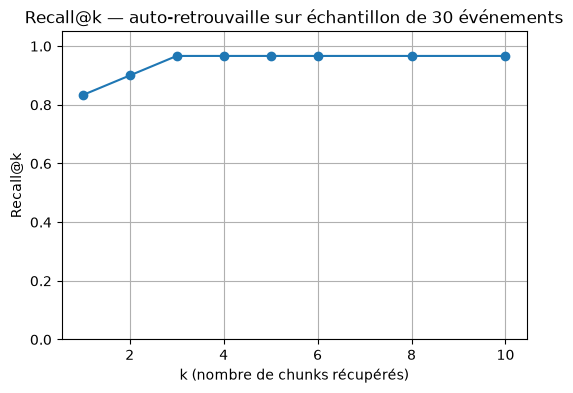

In [31]:
# Visualisation du recall@k pour déterminer nb de k adequat pour le retriever
import random
import matplotlib.pyplot as plt

random.seed(42)
k_max = 10
k_valeurs = [1, 2, 3, 4, 5, 6, 8, 10]
taille_echantillon = 30

echantillon = random.sample(chunks, k=taille_echantillon)

rangs = []
for chunk in echantillon:
    titre = chunk.metadata["titre"]
    resultats = vectorstore.similarity_search(titre, k=k_max)

    uid_source = tuple(chunk.metadata["uids"]) if isinstance(chunk.metadata["uids"], list) else chunk.metadata["uids"]

    rang_trouve = None
    for rang, r in enumerate(resultats, start=1):
        uid_r = tuple(r.metadata["uids"]) if isinstance(r.metadata["uids"], list) else r.metadata["uids"]
        if uid_r == uid_source:
            rang_trouve = rang
            break
    rangs.append(rang_trouve)

recall_par_k = {
    k: sum(1 for rang in rangs if rang is not None and rang <= k) / taille_echantillon
    for k in k_valeurs
}

for k, taux in recall_par_k.items():
    print(f"k={k:>2} -> recall@k = {taux:.0%}")

plt.figure(figsize=(6, 4))
plt.plot(list(recall_par_k.keys()), list(recall_par_k.values()), marker="o")
plt.xlabel("k (nombre de chunks récupérés)")
plt.ylabel("Recall@k")
plt.title("Recall@k — auto-retrouvaille sur échantillon de 30 événements")
plt.ylim(0, 1.05)
plt.grid(True)
plt.show()

On observe que le coude est à 3 chunks, au delà de cela on ne gagne plus en pertinence et on va simplement allourdir le prompt donné au LLM et donc augmenté les couts Token pour rien.

#### Instanciation du retriever

In [32]:
#Créatio du retriever :
retriever = vectorstore.as_retriever(search_kwargs = {"k":3})

In [33]:
#test 
retriever.invoke("Quel evenement à lieu à rennes en octobre sur le thème de la peinture ?")

[Document(id='65d05aad-1aea-47bd-ab99-1ae62463f666', metadata={'uids': [55816614], 'titre': "Exposition photos, peintures, sculptures à l'Orangerie du Thabor - Rennes", 'ville': 'Rennes', 'quartier': 'Thabor - Saint-Hélier - Alphonse Guérin', 'code_postal': '35064', 'departement': 'Ille-et-Vilaine', 'dates': [('2026-04-27T14:00:00+02:00', '2026-04-27T19:30:00+02:00')], 'date_min': '2026-04-27T14:00:00+02:00', 'date_max': '2026-05-03T19:30:00+02:00', 'mots_cles': ['peinture', 'sculpture', 'photos', 'vernissage', 'exposition', 'rennes', 'thabor', 'orangerie', 'art contemporain'], 'url': 'https://openagenda.com/sortir-rennesmetropole/events/exposition-photos-peintures-sculptures-a-lorangerie-du-thabor-rennes-2762424', 'telephones': [], 'emails': [], 'liens': []}, page_content="Mais la planète Bétonnée l'effraie avec l'envolé de ses rêves d'enfant. Accessible à tous avec une entrée libre, l’exposition offre une immersion artistique riche et variée, où chaque discipline dialogue avec les au

#### Prompt systeme

In [34]:
from langchain_core.prompts import ChatPromptTemplate

prompt_systeme = """ 
#RÔLE :
Tu es un assistant spécialisé dans les événements culturels en Brtagne. 
Ton rôle est d'aider les utilisateurs à trouver des événements correspondant à leur demande, en te basant uniquement sur les informations fournies dans le contexte ci-dessous.

# OBJECTIF
Tu dois fournir des informations précises liés à l'événement ou aux événements correspondant à la demande des utilisateurs (titre de l'événement, dates, lieu, conditions d'inscriptions.

# REGLES A RESPECTER STRICTEMENT
N'utilises que les informations contenues dans les chunks que tu reçois dans le contexte fourni. N'invente jamais une information qui n'y figure pas.
Si le contexte ne contient pas l'information demandée, dis le clairement plutôt que de deviner. Par exemple : "Je n'ai pas trouvé l'information demandé dans ma base d'événement."
Si la question porte sur un sujet extérieur aux événements culturels bretons (une biographie, une ville en général, une association en dehors de ce contexte, etc.), précise poliment que cette information ne fait pas partie de ta base de connaissance, sans essayer d'y répondre à partir de connaissances générales.
Réponds toujours en français, de façon claire et concise.
Si plusieurs événements correspondent à la demande, présente-les brièvement plutôt que de n'en choisir qu'un arbitrairement.
N'hésite pas à préciser les informations pratiques utiles (dates, lieu, accessibilité, contact) quand elles sont pertinentes pour la question posée.

#EXEMPLE D'INTERACTION GUIDEE :
Utilisateur : "Quel événement culturel maritime a lieu à Concarneau en juillet ?" 
Assistant attendu : " Bonjour, en juillet, à Concarneau, vous pouvez participer aux filets bleus, dans la ville-close le 15 juillet. La participation à cet événement est gratuit et débutera à partir de 12h."


Contexte : 
{context}"""

prompt_template = ChatPromptTemplate.from_messages([
("system", prompt_systeme),
("human", "{question}"),
])

#### Assemblage de la chaine Langchain

In [35]:
from langchain_core.runnables import RunnablePassthrough
from langchain_core.output_parsers import StrOutputParser

# Création d'une fonction permettant de récupérer les chunks obtenus via le retriever et d'assembler le texte de chaque chunk (page_content donc séparation des métadatas), mais en les séparant par une ligne vide (pour compréhension par le LLM).
def formater_contexte(documents):
    return "\n\n".join(doc.page_content for doc in documents)

# Instanciation de la chaine RAG
chaine_rag = (
    #Dictonnaire dont les valeurs sont des objets Runnable, deux branches : "context", envoie la question dans le retriever 
    #pour obtenir les chunks sémantiquement pertinents et actionne ensuite formater_contexte pour les assembler.
    #La branche "question" qui elle utilise "RunnablePassthrough()" qui ne fait rien d'autre que de renvoyer l'input tel quel.
    {"context" : retriever | formater_contexte, "question" : RunnablePassthrough()} 
    | prompt_template # Injecte le dictionnaire créé dans ChatPromptTemplate qui prend en compte le prompt_systeme et la {question}.
    | llm #Injection du prompt dans le LLM qui créé un AIMessage (contenant réponse texte et métadonnées (nb de token, etc...))
    | StrOutputParser() #Permet de séparer la réponse textuel du AIMessage des métadonnées pour ne nous renvoyer que les métadonnées.
)



In [36]:
import requests

response = requests.post(
    "https://api.mistral.ai/v1/chat/completions",
    headers={
        "Authorization": f"Bearer {API_KEY_MISTRAL}",
        "Content-Type": "application/json",
    },
    json={
        "model": "mistral-small-2603",
        "messages": [{"role": "user", "content": "Bonjour"}],
    },
)
print(response.status_code)
print(response.text)

429
{"object":"error","message":"Rate limit exceeded","type":"rate_limited","param":null,"code":"1300","raw_status_code":429}


In [37]:
#test
reponse = chaine_rag.invoke("Quel evenement à lieu à rennes en octobre sur le thème de la peinture ?")
print(reponse)

HTTPStatusError: Error response 429 while fetching https://api.mistral.ai/v1/chat/completions: {"object":"error","message":"Rate limit exceeded","type":"rate_limited","param":null,"code":"1300","raw_status_code":429}